# Exploring sample data

Bring in an initial 500MB sample dataset from:
<https://datadryad.org/dataset/doi:10.5061/dryad.rr137kn#usage>

In [1]:
import sys
from pathlib import Path

root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))
print("Setting root of the project to:", root)
print("This means we can bring in models from other directories (like ./models)")

Setting root of the project to: /home/kv/education/predicting_DFE
This means we can bring in models from other directories (like ./models)


In [2]:
import pandas as pd

# DATA_FILE_PATH = "../data/sample_data_500mb.sync"
DATA_FILE_PATH = "../data/chromosome_2L.sync"

# Column names provided by documentation at:     <https://datadryad.org/dataset/doi:10.5061/dryad.rr137kn#usage>
# File name of documentation:                    'README_for_F0-F60SNP_CMH_FET_blockID.sync.docx'
columns = [
    'chromosome',
    'position',
    'base',
    'Dsim_Fl_Base_1',
    'Dsim_Fl_Hot_F10_1',
    'Dsim_Fl_Hot_F20_1', 
    'Dsim_Fl_Hot_F30_1',
    'Dsim_Fl_Hot_F40_1', 
    'Dsim_Fl_Hot_F50_1', 
    'Dsim_Fl_Hot_F60_1'
]

raw = pd.read_csv(
    filepath_or_buffer=DATA_FILE_PATH,
    sep='\t', # tab-separated values
    names=columns,
    usecols=columns,
    header=None # no headers provided
)
raw = raw[raw.chromosome == "2L"] # <-- only this chromomosome used in the original paper
raw.head()

,chromosome,position,base,Dsim_Fl_Base_1,Dsim_Fl_Hot_F10_1,Dsim_Fl_Hot_F20_1,Dsim_Fl_Hot_F30_1,Dsim_Fl_Hot_F40_1,Dsim_Fl_Hot_F50_1,Dsim_Fl_Hot_F60_1
0,2L,59,T,0:64:12:0:0:0,0:68:20:0:0:0,0:82:32:0:0:0,0:64:20:0:0:0,0:111:33:0:0:0,0:76:21:0:0:0,0:66:17:0:0:0
1,2L,62,A,70:0:13:0:0:0,69:0:21:0:0:0,90:0:32:0:0:0,67:0:22:0:0:0,122:0:35:0:0:0,82:0:24:0:0:0,70:0:17:0:0:0
2,2L,153,A,112:0:28:0:0:0,108:0:26:0:0:0,153:0:37:0:0:0,79:0:28:0:0:0,162:0:42:0:0:0,107:0:23:0:0:0,100:0:28:0:0:0
3,2L,207,G,0:0:16:130:0:0,0:0:12:116:0:0,0:0:15:158:0:0,0:0:12:132:0:0,0:0:21:204:0:0,0:0:7:125:0:0,0:0:16:113:0:0
4,2L,219,T,8:146:0:0:0:0,9:117:0:0:0:0,11:165:0:0:0:0,10:148:0:0:0:0,15:239:0:0:0:0,12:132:0:0:0:0,15:135:0:0:0:0


# Define alleleFrequency()

Codes are in the form: A:T:C:G:N:del

So, if an allele is in base `T`, with code `0:155:0:75:0:0`, then 75 known mutations have occurred to position `G`.
Allele frequency, then, is the `# mutations / total`.

In [3]:
# Allele count format: [A : T : C : G : N : del]
base_dict = {
    'A': 0,
    'T': 1,
    'C': 2,
    'G': 3,
    'N': 4,   # unused
    'del': 5  # unsued, both defined to be explicit
}

# Mutation Frequency = mutations / total
def alleleFrequency(base, allele_count):
    base_index = base_dict.get(base)
    vector = [int(num) for num in allele_count.split(':')]

    # Sum all values
    total = sum(vector)

    # Error-handle for division-by-zero
    if total == 0:
        return 0.0

    # Find difference between base & total
    base_value = vector[base_index]
    mutations = total - base_value
    freq = mutations / total
    return freq

# Examples
print("Unit test cases")

freq = alleleFrequency(base="T", allele_count="0:200:0:1:0:0")
print(f"{freq}")

freq = alleleFrequency(base="C", allele_count="0:0:100:7:0:0")
print(f"{freq}")

freq = alleleFrequency(base="A", allele_count="40:1:2:3:0:0")
print(f"{freq}")

Unit test cases
0.004975124378109453
0.06542056074766354
0.13043478260869565


# Reorganise the table

In [4]:
# Assign timestamps to the 7 generations
times = {
    'Dsim_Fl_Base_1': 0,
    'Dsim_Fl_Hot_F10_1': 1,
    'Dsim_Fl_Hot_F20_1': 2,
    'Dsim_Fl_Hot_F30_1': 3,
    'Dsim_Fl_Hot_F40_1': 4,
    'Dsim_Fl_Hot_F50_1': 5,
    'Dsim_Fl_Hot_F60_1': 6,
}

time_columns = [
    'Dsim_Fl_Base_1',
    'Dsim_Fl_Hot_F10_1',
    'Dsim_Fl_Hot_F20_1',
    'Dsim_Fl_Hot_F30_1',
    'Dsim_Fl_Hot_F40_1',
    'Dsim_Fl_Hot_F50_1',
    'Dsim_Fl_Hot_F60_1'
]

# Pivot the raw data
df = raw.melt(
    id_vars=['chromosome', 'position', 'base'],
    value_vars=time_columns,
    var_name='generation_id',
    value_name='allele_count'
)

# Pull the time & allele frequency from the original data 
df['time'] = df['generation_id'].map(times)
df['allele_freq'] = [
    alleleFrequency(base, count)
    for base, count in zip(df['base'], df['allele_count'])
]

# Drop waste columns
df.drop(columns=['chromosome', 'generation_id', 'allele_count'], inplace=True)

# Bingo
df

,position,base,time,allele_freq
0,59,T,0,0.157895
1,62,A,0,0.156627
2,153,A,0,0.200000
3,207,G,0,0.109589
4,219,T,0,0.051948
...,...,...,...,...
7481777,21105344,G,6,0.005682
7481778,21105476,A,6,0.000000
7481779,21105537,C,6,0.229592
7481780,21105570,A,6,0.037037


# Visualisations

/tmp/nix-shell.v63TRs/ipykernel_11751/3340129805.py:5: UserWarning: 
The palette list has fewer values (1) than needed (3003) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


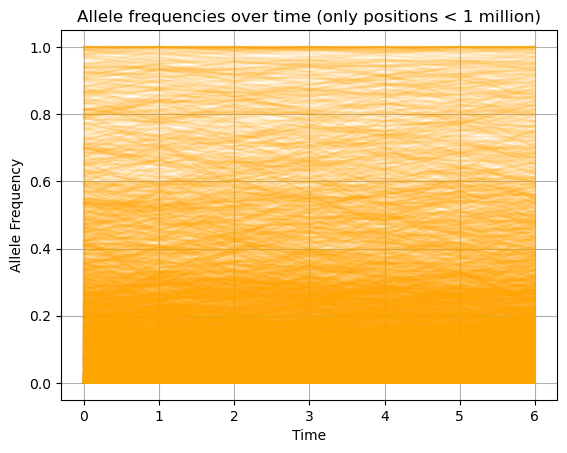

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Allele frequency over time, for every position below 1 million (trivial)
sns.lineplot(
    data=df[df.position < 1_000_000],
    x='time',
    y='allele_freq',
    hue='position',
    palette=['orange'],
    alpha=.1,
    legend=False
)
plt.title("Allele frequencies over time (only positions < 1 million)")
plt.xlabel("Time")
plt.ylabel("Allele Frequency")
plt.grid()
plt.show()

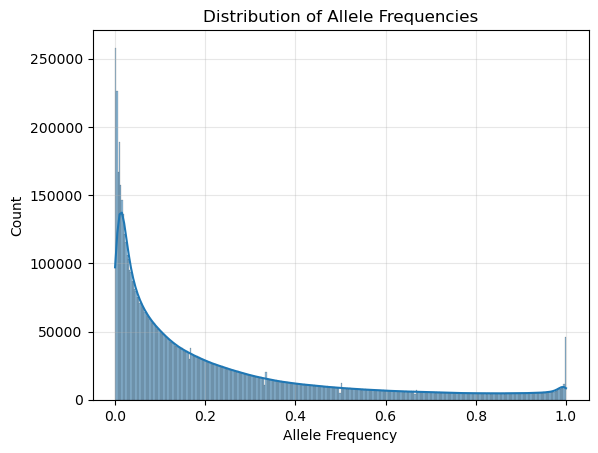

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Allele Frequency over time
sns.histplot(data=df, x='allele_freq', kde=True)
plt.title("Distribution of Allele Frequencies")
plt.xlabel("Allele Frequency")
plt.grid(alpha=.3)
plt.show()

# Allele Frequency over time, colored by generation
# All generations seem to follow the same distribution
# sns.histplot(data=df, x='allele_freq', hue='time')
# plt.title("Coloring by generation shows no effect")
# plt.xlabel("Allele Frequency")
# plt.grid(alpha=.3)
# plt.show()

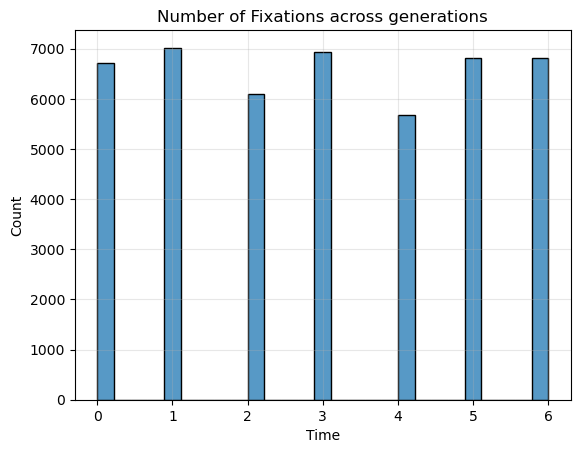

In [6]:
# Number of fixations for each generation
sns.histplot(data=df[df['allele_freq'] == 1], x='time')
plt.title("Number of Fixations across generations")
plt.xlabel("Time")
plt.grid(alpha=.3)
plt.show()

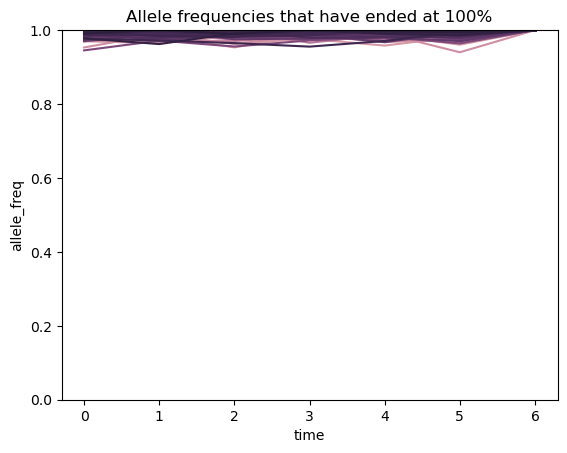

In [50]:
g = df.groupby("position")
at_6_is_1 = g.apply(
    lambda x: x.loc[x["time"] == 6, "allele_freq"].eq(1).any(),
    include_groups=False,
)
before_6_not_1 = g.apply(
    lambda x: x.loc[x["time"] < 6, "allele_freq"].ne(1).any(),
    include_groups=False,
)
matches = at_6_is_1 & before_6_not_1
positions = matches[matches].index

sns.lineplot(data=df[df.position.isin(positions)], x='time', y='allele_freq', hue='position', errorbar=None, legend=None)
plt.title("Allele frequencies that have ended at 100%")
plt.ylim(0, 1)
plt.show()

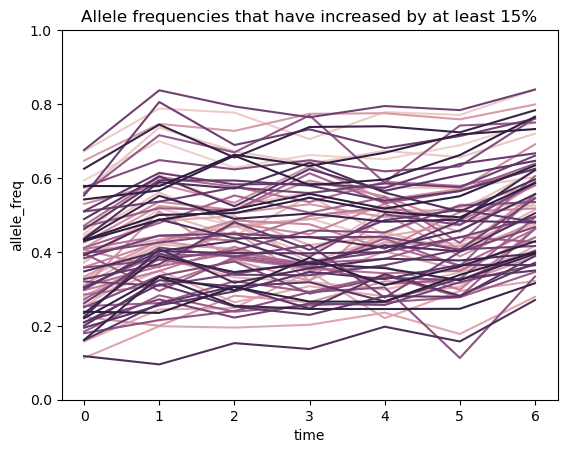

In [52]:
g = df.groupby("position")["allele_freq"]
changed = (g.last() - g.first()) > 0.15
positions = changed[changed].index

sns.lineplot(data=df[df.position.isin(positions)], x='time', y='allele_freq', hue='position', errorbar=None, legend=None)
plt.title("Allele frequencies that have increased by at least 15%")
plt.ylim(0, 1)
plt.show()

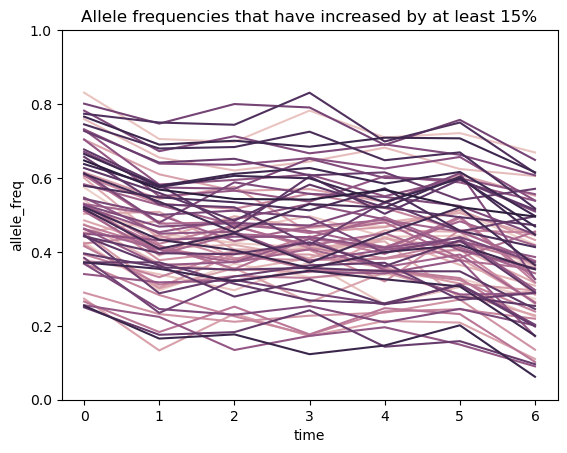

In [54]:
g = df.groupby("position")["allele_freq"]
changed = (g.last() - g.first()) < -0.15
positions = changed[changed].index

sns.lineplot(data=df[df.position.isin(positions)], x='time', y='allele_freq', hue='position', errorbar=None, legend=None)
plt.title("Allele frequencies that have decreased by at least 15%")
plt.ylim(0, 1)
plt.show()

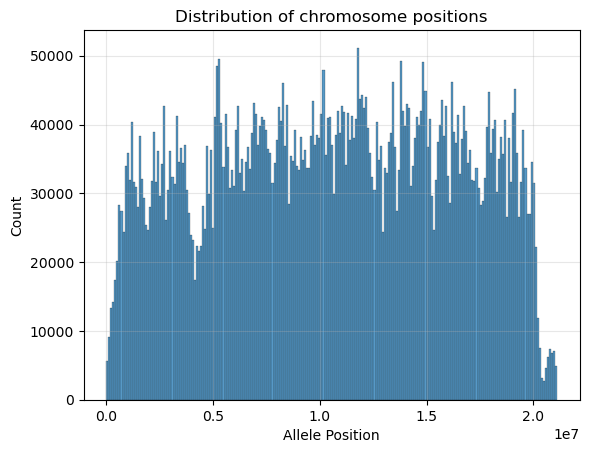


Median: 	10533599.639178874
Mean:   	10658459.0
Range:  	59 ... 21105619
N:      	7481782



In [37]:
plt.title("Distribution of chromosome positions")
sns.histplot(data=df, x='position')
plt.xlabel("Allele Position")
plt.grid(alpha=.3)
plt.show()

mean = df['position'].mean()
median = df['position'].median()
lowest = df['position'].min()
highest = df['position'].max()
n = df['position'].count()
summary = f'''
Median: \t{mean}
Mean:   \t{median}
Range:  \t{lowest} ... {highest}
N:      \t{n}
'''
print(summary)

In [46]:
# Log scale

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()

def update(time):
    ax.clear()
    time_data = df[df.time == time]
    sns.histplot(data=time_data, x='allele_freq', ax=ax, kde=True, log_scale=True)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 20_000)
    ax.set_title(f"Allele Frequency at Time: {time}")
    ax.set_xlabel("Allele Frequency")
    ax.grid(alpha=.3)

ani = FuncAnimation(fig, update, frames=range(0, 7), interval=500, repeat=False)
plt.close()

HTML(ani.to_jshtml())

/nix/store/vyf05n4xlxm7mhb3rsv5c7wl36brna52-python3-3.13.13-env/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/tmp/nix-shell.1KZtwT/ipykernel_9232/2655419206.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 1)
/nix/store/vyf05n4xlxm7mhb3rsv5c7wl36brna52-python3-3.13.13-env/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/tmp/nix-shell.1KZtwT/ipykernel_9232/2655419206.py:12: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 1)
/nix/store/vyf05n4xlxm7mhb3rsv5c7wl36brna52-python3-3.13.13-env/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/tmp/nix-shell.1KZtwT/

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots()

def update(time):
    ax.clear()
    time_data = df[df.time == time]
    sns.histplot(data=time_data, x='allele_freq', ax=ax)
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(0, 75_000)
    ax.set_title(f"Allele Frequency at Time: {time}")
    ax.set_xlabel("Allele Frequency")
    ax.grid(alpha=.3)

ani = FuncAnimation(fig, update, frames=range(0, 7), interval=500, repeat=False)
plt.close()

HTML(ani.to_jshtml())